<a href="https://colab.research.google.com/github/Sebastianelli-Nicola/Traffic-Driven-EV-Queuing-Predictor/blob/main/experimental_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting del Traffico e Occupazione Stazioni di Ricarica EV
**Pipeline Sperimentale e Valutazione dei Modelli Predittivi**

Questo notebook implementa l'architettura di Machine Learning progettata per la previsione a breve termine del traffico veicolare. L'infrastruttura di codice è strutturata per rispondere alle specifiche delineate nel piano di progetto, suddividendo il lavoro in due fasi operative principali.

---

## Fase 2: Definizione del Protocollo Sperimentale

In questa prima fase, l'approccio metodologico ai dati è stato completamente ridefinito per simulare in modo accurato un ambiente di produzione reale, superando i limiti dei test statici.

*   **Implementazione della Sliding Window:** Il tradizionale partizionamento statico dei dati (80% per il training, 20% per il test) è stato abbandonato. Il sistema adotta ora un approccio dinamico basato sulla tecnica della *finestra scorrevole* (Sliding Window).
*   **Impostazione dei Test Indipendenti:** L'infrastruttura isola un periodo di prova finale (es. le ultime due settimane disponibili). All'interno di tale periodo, ogni singola giornata costituisce un test indipendente. Per addestrare il modello in vista di ogni test, il sistema sfrutta quasi tutti i dati storici a disposizione.
*   **Aggregazione Temporale:** L'obiettivo non è una previsione generica, ma puntuale. Per questo motivo, l'ingestione dei dati, l'addestramento e i risultati dei test sono strutturati e aggregati in **slot temporali esatti della durata di 30 minuti**.

---

## Fase 3: Esecuzione Computazionale e Calcolo Metriche

Questa sezione rappresenta il cuore operativo. È progettata per eseguire computazioni intensive in background (elaborazione offline) ed estrarre metriche per un futuro deployment del sistema.

*   **Selezione dei Modelli Predittivi:** Per ora sono stati inseriti solo alcuni modelli (Random Forest, SARIMA, LSTM). A queste è stata integrata la sperimentazione di **Neural Prophet**, un'architettura moderna basata su PyTorch.
*   **Elaborazione Offline Automatizzata:** Le routine di addestramento e validazione (Evaluation Loop) sono incapsulate in script automatizzati. Questo permette l'esecuzione autonoma e non supervisionata di interi batch di calcolo.
*   **Tracciamento delle Tempistiche:** Il sistema registra puntualmente le performance hardware e software. Viene misurato il tempo di *Training* (calcolo pesante eseguito offline) e la latenza di *Predizione*. Quest'ultima metrica è critica: nel sistema a regime, il calcolo predittivo dovrà risultare estremamente veloce per poter essere ricalcolato continuamente in modalità online.
*   **Analisi del Decadimento dell'Errore nel Tempo:** Per determinare il ciclo di vita utile del modello, l'orizzonte di previsione massimo viene spinto fino a **2 o 3 giorni**. Il codice calcola e registra l'errore commesso per *ogni singolo slot di 30 minuti*. Mappando come si modifica tale errore all'allontanarsi dal momento della previsione, è possibile stabilire oggettivamente l'affidabilità temporale del sistema e determinare la frequenza ideale per il riaddestramento.

## 1: Ingestion & Pre-Processing
Questa sezione si occupa di importare i dati grezzi da Google Drive, isolare le misurazioni della singola stazione e aggregare i dati in slot temporali esatti da **30 minuti**. Vengono inoltre estratte le feature temporali di base (ora, giorno, weekend) che i modelli utilizzeranno per apprendere i pattern comportamentali.

In [1]:
# Installa le librerie che non sono native in Google Colab
!pip install neuralprophet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.4/145.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requ

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from google.colab import drive
import warnings

# Ignoriamo i warning non critici per mantenere l'output pulito durante le stampe
warnings.filterwarnings('ignore')

# =========================================================================
# 1. SETUP DELL'AMBIENTE E CONNESSIONE DATI
# =========================================================================
# Montiamo Google Drive per poter leggere e scrivere i file
drive.mount('/content/drive')

# Definiamo i percorsi base (PATH) dove si trovano i file
PATH = '/content/drive/MyDrive/Colab Notebooks/TIROCINIO/dataset_ricostruito/'
PATH_RISULTATI = '/content/drive/MyDrive/Colab Notebooks/TIROCINIO/'
FILE_NAME = 'traffico_r.csv'

# Creiamo una cartella dedicata SOLO ai risultati
RESULTS_DIR = os.path.join(PATH_RISULTATI, 'Risultati_Esperimenti/')

# Verifica se la cartella esiste già, altrimenti la crea
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    print(f" Cartella risultati creata: {RESULTS_DIR}")
else:
    print(f" Cartella risultati trovata: {RESULTS_DIR}")


# =========================================================================
# 2. FUNZIONI DI CARICAMENTO E PRE-PROCESSING
# =========================================================================
def carica_dataset_completo(nome_file):
    """
    Legge il file CSV una sola volta in memoria centrale.
    Questo evita di far crashare la RAM ricaricandolo per ogni stazione.
    """
    print("Lettura del dataset completo in corso...")
    percorso_completo = os.path.join(PATH, nome_file)

    # Controllo di sicurezza: verifichiamo che il file esista prima di leggerlo
    if not os.path.exists(percorso_completo):
        raise FileNotFoundError(f"File {nome_file} non trovato nel percorso {PATH}")

    # Caricamento tramite pandas e conversione immediata della colonna 'timestamp' in formato Datetime
    df = pd.read_csv(percorso_completo)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

def pre_processing_stazione(df_completo, id_stazione):
    """
    Estrae i dati di una specifica stazione dal dataset globale,
    li regolarizza a slot di 30 minuti e genera le feature temporali.
    """
    # 1. Filtraggio: teniamo solo le righe dove id_stazione corrisponde a quello richiesto
    df_stazione = df_completo[df_completo['id_stazione'] == id_stazione].copy()

    # 2. Impostiamo il timestamp come Indice del dataframe e lo ordiniamo cronologicamente
    df_stazione.set_index('timestamp', inplace=True)
    df_stazione.sort_index(inplace=True)

    # 3. Aggregazione temporale (Resampling)
    # Raggruppa i dati in blocchi esatti di 30 minuti calcolando la media del traffico ('differenza')
    df_resampled = df_stazione[['differenza']].resample('30min').mean()

    # Se il resampling crea dei 'buchi' (NaN) perché in quei 30 min non c'erano dati,
    # usiamo ffill() (forward fill) per copiare il valore dell'ultimo slot valido noto.
    df_resampled['differenza'] = df_resampled['differenza'].ffill()

    # 4. Feature Engineering: Creazione delle variabili indipendenti (X) per i modelli
    # Estraiamo l'ora del giorno (0-23)
    df_resampled['hour'] = df_resampled.index.hour
    # Estraiamo il giorno della settimana (0=Lunedì, 6=Domenica)
    df_resampled['dayofweek'] = df_resampled.index.dayofweek
    # Creiamo una variabile binaria (1/0) per indicare se è fine settimana (Sabato o Domenica)
    df_resampled['is_weekend'] = (df_resampled.index.dayofweek >= 5).astype(int)

    # Eliminiamo le primissime righe se contengono valori nulli impossibili da riempire
    df_resampled.dropna(inplace=True)

    return df_resampled

# Avviamo il caricamento
dataset_raw = carica_dataset_completo(FILE_NAME)

Mounted at /content/drive
 Cartella risultati trovata: /content/drive/MyDrive/Colab Notebooks/TIROCINIO/Risultati_Esperimenti/
Lettura del dataset completo in corso...


## 2: Sliding Window Dinamica
In questo blocco viene abbandonato il partizionamento statico (80/20). La funzione genera dinamicamente finestre di addestramento e test.
Utilizzando la modalità `test_on_end=True` e `train_days='auto'`, il sistema si ancora matematicamente all'ultimo giorno del dataset, calcolando tutto lo storico passato disponibile e generando iterazioni (folds) per testare rigorosamente le misurazioni più recenti.

In [2]:
from datetime import timedelta

def sliding_window_generator(df, train_days='auto', test_days=1, step_days=1, max_folds=14, test_on_end=True):
    """
    Funzione di sliding window.
    Usa 'yield' per rilasciare un pezzo alla volta ottimizzando la memoria RAM.
    """
    # Controllo di sicurezza sull'indice
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("L'indice del dataset deve essere in formato Datetime!")

    start_date = df.index.min() # Data più vecchia
    end_date = df.index.max()   # Data più recente
    fold_counter = 1

    if test_on_end:
        # Vogliamo che l'ultimo giorno di test coincida con la fine del dataset
        # Calcoliamo quanti giorni totali durerà il periodo di test (es. 14 iterazioni * 1 giorno = 14 giorni)
        giorni_totali_test = max_folds * step_days

        # Calcoliamo la data in cui deve partire il PRIMO test
        inizio_primo_test = end_date - timedelta(days=giorni_totali_test)

        # Se richiesto, calcoliamo in automatico quanti giorni storici ci sono prima di quel test
        if train_days == 'auto':
            train_days = (inizio_primo_test - start_date).days

        # Impostiamo la data di partenza del primissimo blocco di addestramento
        current_start = inizio_primo_test - timedelta(days=train_days)

        # Controllo se il dataset è troppo corto per questa configurazione
        if current_start < start_date:
            raise ValueError(f"Dataset troppo corto per {max_folds} test e {train_days} storico!")
    else:
        # Modalità classica: parte dall'inizio del file
        current_start = start_date

    # Ciclo infinito che verrà interrotto dai 'break'
    while True:
        # CONDIZIONE DI STOP 1: Abbiamo raggiunto il numero massimo di finestre richieste (es. 14)
        if max_folds is not None and fold_counter > max_folds:
            break

        # Calcolo dei margini temporali del fold attuale
        train_end = current_start + timedelta(days=train_days)
        test_end = train_end + timedelta(days=test_days)

        # CONDIZIONE DI STOP 2: Il test supererebbe l'ultima riga del dataset
        if test_end > end_date:
            break

        # SLICING: Tagliamo fisicamente i dati.
        # Usiamo '<' per l'estremo destro per evitare sovrapposizioni tra train e test (Data Leakage)
        train_data = df[(df.index >= current_start) & (df.index < train_end)]
        test_data = df[(df.index >= train_end) & (df.index < test_end)]

        # Restituiamo i dati al blocco chiamante e mettiamo in pausa la funzione
        yield fold_counter, train_data, test_data

        # SCORRIMENTO: Spostiamo l'inizio in avanti di 'step_days' (es. 1 giorno) e ripartiamo
        current_start += timedelta(days=step_days)
        fold_counter += 1

##3: Evaluation Loop Modulare & Wrappers
Questo blocco definisce il motore di valutazione che calcola tempi e metriche offline/online, registrando l'errore commesso in ciascun singolo slot. Contiene inoltre i Wrappers degli algoritmi: Random Forest, Neural Prophet, Stacked LSTM e SARIMA.

In [3]:
import time
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from neuralprophet import NeuralProphet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import logging

import torch
import neuralprophet

# Soppressione dei log di PyTorch e TensorFlow
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
tf.get_logger().setLevel('ERROR')

# =========================================================================
# FIX DEFINITIVO PER PYTORCH 2.6+: Disabilitazione Globale 'weights_only'
# =========================================================================
# Poiché NeuralProphet salva e carica decine di oggetti diversi (inclusi
# moduli interni di PyTorch come SmoothL1Loss), la whitelist non basta più.
# Essendo questo un ambiente sicuro, "patchiamo" torch.load per spegnere il blocco.

import torch

# Salviamo la funzione originale di PyTorch
_original_torch_load = torch.load

# Creiamo una funzione "truccata" che imposta sempre weights_only=False
def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

# Sostituiamo la funzione originale nel motore di PyTorch
torch.load = _patched_torch_load

# =====================================================================
# VALUTAZIONE
# =====================================================================
def run_evaluation_loop_modulare(generatore, model_wrapper, path_salvataggio):
    print(f" -> Loop: {model_wrapper.model_name}", end=" | ")
    tutti_i_risultati = []

    for fold, train_df, test_df in generatore:
        if train_df.empty or test_df.empty: continue
        y_test = test_df['differenza'].values

        start_train = time.perf_counter()
        model_wrapper.train(train_df)
        train_time = time.perf_counter() - start_train

        start_pred = time.perf_counter()
        y_pred = model_wrapper.predict(train_df, test_df)
        pred_time = time.perf_counter() - start_pred

        fold_result = {
            'modello': model_wrapper.model_name,
            'id_finestra': fold,
            'data_test': test_df.index.min().date(),
            'tempo_training_sec': round(train_time, 4),
            'latenza_ms_per_slot': round((pred_time / len(y_test)) * 1000, 4),
            'rmse_globale': round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            'mae_globale': round(mean_absolute_error(y_test, y_pred), 3)
        }

        for i in range(len(y_test)):
            fold_result[f'errore_assoluto_slot_{i+1}'] = round(abs(y_test[i] - y_pred[i]), 3)

        tutti_i_risultati.append(fold_result)
        df_temp = pd.DataFrame([fold_result])

        if not os.path.exists(path_salvataggio):
            df_temp.to_csv(path_salvataggio, index=False)
        else:
            df_temp.to_csv(path_salvataggio, mode='a', header=False, index=False)

    print("Completato.")
    return pd.DataFrame(tutti_i_risultati)

# =====================================================================
# WRAPPERS DEI MODELLI
# =====================================================================

class RandomForestWrapper:
    def __init__(self):
        self.model_name = "RandomForest"
        self.model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        self.features = ['hour', 'dayofweek', 'is_weekend']

    def train(self, train_df):
        self.model.fit(train_df[self.features].values, train_df['differenza'].values)

    def predict(self, train_df, test_df):
        return np.maximum(0, self.model.predict(test_df[self.features].values))


class NeuralProphetWrapper:
    def __init__(self, epochs=50):
        self.model_name = "NeuralProphet"
        self.epochs = epochs

    def train(self, train_df):
        df_np = pd.DataFrame({'ds': train_df.index, 'y': train_df['differenza'].values})
        self.model = NeuralProphet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True, epochs=self.epochs)
        self.model.fit(df_np, freq="30min", progress=None, minimal=True)

    def predict(self, train_df, test_df):
        df_np = pd.DataFrame({'ds': train_df.index, 'y': train_df['differenza'].values})
        future = self.model.make_future_dataframe(df_np, periods=len(test_df))
        return np.maximum(0, self.model.predict(future)['yhat1'].values)


class StackedLSTMWrapper:
    def __init__(self, look_back=48, epochs=20):
        self.model_name = "Stacked_LSTM"
        self.look_back = look_back
        self.epochs = epochs
        self.scaler = MinMaxScaler(feature_range=(0, 1))

    def train(self, train_df):
        scaled = self.scaler.fit_transform(train_df[['differenza']].values)
        X, Y = [], []
        for i in range(len(scaled) - self.look_back):
            X.append(scaled[i:(i + self.look_back), 0])
            Y.append(scaled[i + self.look_back, 0])

        X, Y = np.array(X), np.array(Y)
        X = np.reshape(X, (X.shape[0], X.shape[1], 1))

        self.model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(self.look_back, 1)),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        self.model.compile(loss='mse', optimizer='adam')
        self.model.fit(X, Y, epochs=self.epochs, batch_size=64, verbose=0)

    def predict(self, train_df, test_df):
        preds = []
        batch = train_df[['differenza']].values[-self.look_back:]
        batch_scaled = self.scaler.transform(batch).reshape(1, self.look_back, 1)

        for _ in range(len(test_df)):
            p_scaled = self.model.predict(batch_scaled, verbose=0)[0]
            preds.append(max(0, self.scaler.inverse_transform([p_scaled])[0, 0]))
            batch_scaled = np.append(batch_scaled[:, 1:, :], [[[p_scaled[0]]]], axis=1)
        return np.array(preds)


class SARIMAXWrapper:
    def __init__(self, order, seasonal_order):
        self.model_name = "SARIMA"
        self.order = order
        self.seasonal_order = seasonal_order

    def train(self, train_df):
        self.model = sm.tsa.SARIMAX(train_df['differenza'].values,
                                    order=self.order,
                                    seasonal_order=self.seasonal_order,
                                    enforce_stationarity=False,
                                    enforce_invertibility=False)
        self.fitted = self.model.fit(disp=False)

    def predict(self, train_df, test_df):
        return np.maximum(0, self.fitted.get_forecast(steps=len(test_df)).predicted_mean)

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


## 4: Esecuzione Batch Multi-Stazione
 Lo script esegue un loop su ogni stazione disponibile nel dataset. Per ogni stazione, esegue l'addestramento e il test sui 4 modelli, spingendo la previsione a **2 giorni futuri (48h)** su un set di test di **14 giorni (finestre)**.
*Nota: i parametri SARIMA sono pre-calcolati offline tramite script "una tantum" per prevenire colli di bottiglia.*

In [4]:
import time
import datetime
import os

if __name__ == "__main__":

    # =========================================================================
    # PARAMETRI DEL PROTOCOLLO SPERIMENTALE
    # =========================================================================
    TEST_GIORNI_FUTURI = 2
    MAX_ITERAZIONI = 14

    stazioni_disponibili = dataset_raw['id_stazione'].unique()

    # =========================================================================
    # PARAMETRI SARIMA (Pre-calcolati con l'altro script)
    # =========================================================================
    PARAMETRI_SARIMA_STAZIONI = {
        1: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        2: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        3: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        4: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        5: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        6: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        7: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        8: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
        9: {'order': (3, 0, 1), 'seasonal_order': (0, 1, 1, 48)},
    }

    # =========================================================================
    # MOTORE DI STIMA ETA (Indipendente per modello)
    # =========================================================================
    inizio_globale = time.time()
    stazioni_valide_stimate = len(stazioni_disponibili)

    # Dizionario che tiene traccia dei tempi specifici per ogni algoritmo
    statistiche_modelli = {
        "Random Forest": {"completati": 0, "tempo_totale": 0.0},
        "SARIMA": {"completati": 0, "tempo_totale": 0.0},
        "Neural Prophet": {"completati": 0, "tempo_totale": 0.0},
        "Stacked LSTM": {"completati": 0, "tempo_totale": 0.0}
    }

    def stampa_progresso_eta_dinamico(nome_modello, tempo_inizio_modello):
        durata = time.time() - tempo_inizio_modello

        # 1. Aggiorniamo le statistiche specifiche di QUESTO modello
        statistiche_modelli[nome_modello]["completati"] += 1
        statistiche_modelli[nome_modello]["tempo_totale"] += durata

        # 2. Calcoliamo l'ETA Globale sommando le stime di ogni singolo modello
        eta_secondi_totali = 0
        for mod, stats in statistiche_modelli.items():
            rimanenti = stazioni_valide_stimate - stats["completati"]

            # Calcoliamo la stima solo se il modello ha fatto almeno un giro per avere una media
            if stats["completati"] > 0:
                tempo_medio = stats["tempo_totale"] / stats["completati"]
                eta_secondi_totali += (tempo_medio * rimanenti)

        eta_formattato = str(datetime.timedelta(seconds=int(eta_secondi_totali)))

        print(f" OK  {nome_modello} completato in {int(durata)} sec.")

        # Durante la primissima stazione, l'ETA sarà parziale finché tutti i 4 modelli non finiscono un giro
        if statistiche_modelli["Stacked LSTM"]["completati"] == 0:
            print(f"   ETA Globale: In calcolo... (sarà preciso dopo la Stazione 1)\n")
        else:
            print(f"   ETA Fine Elaborazione Globale: ~ {eta_formattato}\n")


    # =========================================================================
    # AVVIO ELABORAZIONE
    # =========================================================================
    print("\n" + "#"*70)
    print(" INIZIO ELABORAZIONE BATCH MULTI-STAZIONE")
    print(f" Orizzonte di predizione : {TEST_GIORNI_FUTURI} giorni")
    print(f" Iterazioni di test      : {MAX_ITERAZIONI} finestre")
    print(f" Stazioni in analisi     : {stazioni_valide_stimate}")
    print("#"*70 + "\n")

    for st_id in stazioni_disponibili:
        print(f"{'='*70}\n--- AVVIO PIPELINE: STAZIONE {st_id} ---\n{'='*70}")

        dataset_stazione = pre_processing_stazione(dataset_raw, st_id)

        # Se la stazione viene saltata, scaliamo il totale per non sballare le stime ETA
        if len(dataset_stazione) < 48 * 30:
            print(f" -> Stazione {st_id} saltata (Dati insufficienti, meno di 30 giorni)")
            stazioni_valide_stimate -= 1
            continue

        # 1. Random Forest
        print(f" [Staz {st_id}] Avvio Random Forest...")
        t0 = time.time()
        gen_rf = sliding_window_generator(dataset_stazione, train_days='auto', test_days=TEST_GIORNI_FUTURI, step_days=1, max_folds=MAX_ITERAZIONI, test_on_end=True)
        path_rf = os.path.join(RESULTS_DIR, f"risultati_RF_Staz_{st_id}.csv")
        run_evaluation_loop_modulare(gen_rf, RandomForestWrapper(), path_rf)
        stampa_progresso_eta_dinamico("Random Forest", t0)

        # # 2. SARIMA
        # print(f" [Staz {st_id}] Avvio SARIMA...")
        # t0 = time.time()
        # if st_id in PARAMETRI_SARIMA_STAZIONI:
        #     p_order = PARAMETRI_SARIMA_STAZIONI[st_id]['order']
        #     p_seasonal = PARAMETRI_SARIMA_STAZIONI[st_id]['seasonal_order']
        #     gen_sarima = sliding_window_generator(dataset_stazione, train_days='auto', test_days=TEST_GIORNI_FUTURI, step_days=1, max_folds=MAX_ITERAZIONI, test_on_end=True)
        #     path_sarima = os.path.join(RESULTS_DIR, f"risultati_SARIMA_Staz_{st_id}.csv")
        #     run_evaluation_loop_modulare(gen_sarima, SARIMAXWrapper(order=p_order, seasonal_order=p_seasonal), path_sarima)
        #     stampa_progresso_eta_dinamico("SARIMA", t0)
        # else:
        #     print(f"  -> SARIMA saltato (Parametri mancanti per Staz {st_id})\n")
        #     # Segniamo fittiziamente il modello come completato a 0 secondi per far tornare la matematica dell'ETA
        #     statistiche_modelli["SARIMA"]["completati"] += 1

        # 3. Neural Prophet
        print(f" [Staz {st_id}] Avvio Neural Prophet...")
        t0 = time.time()
        gen_np = sliding_window_generator(dataset_stazione, train_days='auto', test_days=TEST_GIORNI_FUTURI, step_days=1, max_folds=MAX_ITERAZIONI, test_on_end=True)
        path_np = os.path.join(RESULTS_DIR, f"risultati_NP_Staz_{st_id}.csv")
        run_evaluation_loop_modulare(gen_np, NeuralProphetWrapper(epochs=50), path_np)
        stampa_progresso_eta_dinamico("Neural Prophet", t0)

        # 4. Stacked LSTM
        print(f" [Staz {st_id}] Avvio Stacked LSTM...")
        t0 = time.time()
        gen_lstm = sliding_window_generator(dataset_stazione, train_days='auto', test_days=TEST_GIORNI_FUTURI, step_days=1, max_folds=MAX_ITERAZIONI, test_on_end=True)
        path_lstm = os.path.join(RESULTS_DIR, f"risultati_LSTM_Staz_{st_id}.csv")
        run_evaluation_loop_modulare(gen_lstm, StackedLSTMWrapper(epochs=20), path_lstm)
        stampa_progresso_eta_dinamico("Stacked LSTM", t0)

    tempo_totale_fine = str(datetime.timedelta(seconds=int(time.time() - inizio_globale)))
    print(f"\n !!! ELABORAZIONE COMPLETA CONCLUSA IN {tempo_totale_fine} !!! ")


######################################################################
 INIZIO ELABORAZIONE BATCH MULTI-STAZIONE
 Orizzonte di predizione : 2 giorni
 Iterazioni di test      : 14 finestre
 Stazioni in analisi     : 9
######################################################################

--- AVVIO PIPELINE: STAZIONE 1 ---
 [Staz 1] Avvio Random Forest...
 -> Loop: RandomForest | 

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 99.991% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 99.991% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 30min
INFO:NP.df_utils:Defined frequency is equal to major frequency - 30min
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO:NP.config:Setting normalization to global as only one dataframe provided for training.


Completato.
 OK  Random Forest completato in 8 sec.
   ETA Globale: In calcolo... (sarà preciso dopo la Stazione 1)

 [Staz 1] Avvio Neural Prophet...
 -> Loop: NeuralProphet | 

INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 128
INFO:NP.config:Auto-set batch_size to 128
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (86) is too small than the required number                     for the learning rate finder (251). The results might not be optimal.


Finding best initial lr:   0%|          | 0/251 [00:00<?, ?it/s]

...

Finding best initial lr:   0%|          | 0/251 [00:00<?, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 99.991% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 99.991% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 30min
INFO:NP.df_utils:Defined frequency is equal to major frequency - 30min
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 98.958% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 98.958% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 30min
INFO:NP.df_utils:Defined frequency is equal to major frequency - 30min
INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 98.958% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 98.958% of the data.
INFO - (NP.df_utils.

Finding best initial lr:   0%|          | 0/251 [00:00<?, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 99.991% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 99.991% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 30min
INFO:NP.df_utils:Defined frequency is equal to major frequency - 30min
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 98.958% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 98.958% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - 30min
INFO:NP.df_utils:Defined frequency is equal to major frequency - 30min
INFO - (NP.df_utils._infer_frequency) - Major frequency 30min corresponds to 98.958% of the data.
INFO:NP.df_utils:Major frequency 30min corresponds to 98.958% of the data.
INFO - (NP.df_utils.

Completato.
 OK  Neural Prophet completato in 283 sec.
   ETA Fine Elaborazione Globale: ~ 0:09:56

 [Staz 9] Avvio Stacked LSTM...
 -> Loop: Stacked_LSTM | Completato.
 OK  Stacked LSTM completato in 595 sec.
   ETA Fine Elaborazione Globale: ~ 0:00:00


 !!! ELABORAZIONE COMPLETA CONCLUSA IN 2:12:09 !!! 


## 5: Analisi Globale del Decadimento dell'Errore
Da eseguire alla fine di tutte le elaborazioni. Lo script aggrega matematicamente i CSV generati su tutte le stazioni (Media Globale) per mappare come si deteriora l'affidabilità predittiva da 0 a 48 ore. La visualizzazione aiuta a decretare empiricamente ogni quanto il sistema reale necessita di una fase Offline di riaddestramento.

Legge tutti i CSV generati, media gli errori e stampa il grafico del ciclo di vita dei modelli.

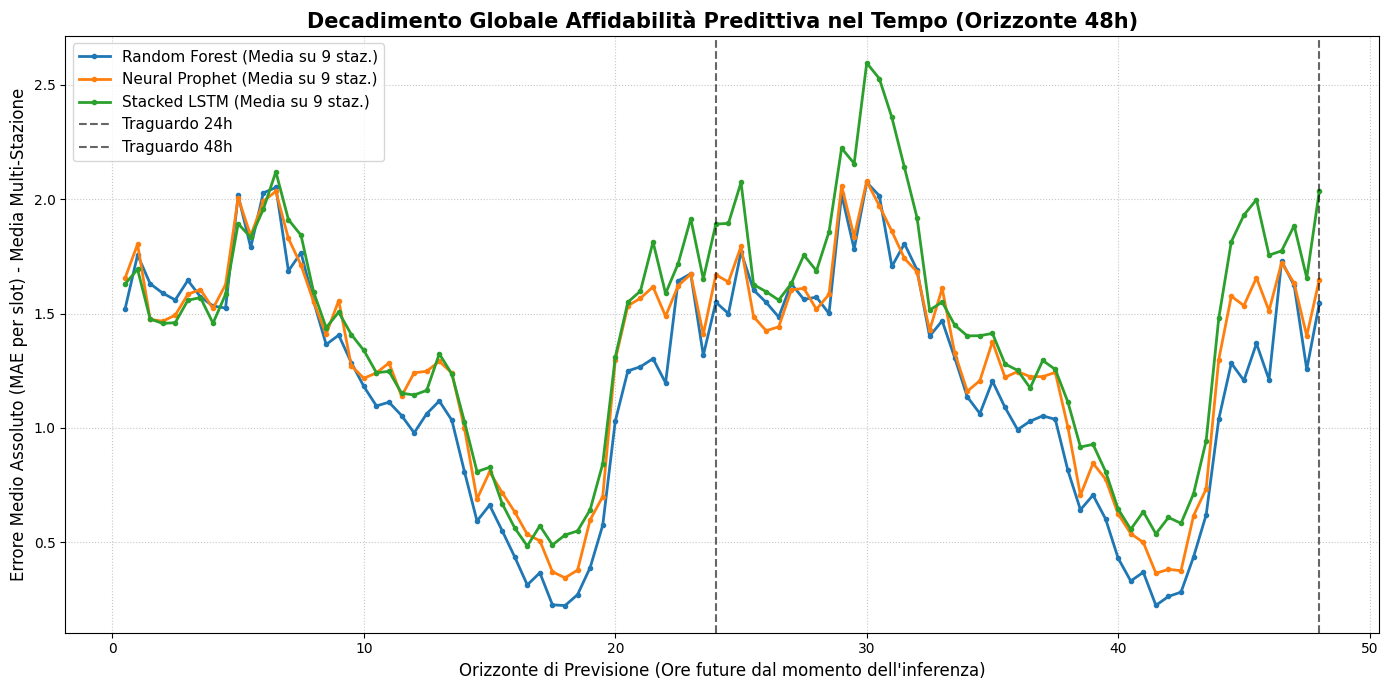

In [2]:
import matplotlib.pyplot as plt

def analizza_decadimento_globale(prefissi_modelli, labels_modelli):
    """
    Trova i CSV di ogni modello, aggrega le colonne degli errori per singolo slot e
    stampa un grafico temporale.
    """
    plt.figure(figsize=(14, 7))
    # Palette di colori leggibile e professionale per i 4 modelli
    colori = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    dati_trovati = False

    # Per ogni modello (es. "risultati_RF_Staz_")...
    for idx, prefisso in enumerate(prefissi_modelli):
        # Usiamo glob per trovare TUTTI i file che matchano col prefisso (tutte le 9 stazioni)
        pattern = os.path.join(RESULTS_DIR, f"{prefisso}*.csv")
        file_modello = glob.glob(pattern)

        if len(file_modello) > 0:
            dati_trovati = True
            errori_tutte_stazioni = []

            # Leggiamo i file CSV di tutte le stazioni uno per uno
            for path_csv in file_modello:
                df_ris = pd.read_csv(path_csv)

                # Isoliamo solo le 96 colonne che si chiamano 'errore_assoluto_slot_X'
                colonne_errore = [col for col in df_ris.columns if col.startswith('errore_assoluto_slot_')]

                # Facciamo la media in VERTICALE: per ogni slot, qual è stato l'errore medio sulle 14 finestre di test?
                errore_stazione_per_slot = df_ris[colonne_errore].mean(axis=0).values
                errori_tutte_stazioni.append(errore_stazione_per_slot)

            # Ora facciamo la media GLOBALE su tutte le stazioni (es. l'errore medio della RF allo slot 1 su tutte le 9 stazioni)
            errore_medio_globale = np.mean(errori_tutte_stazioni, axis=0)

            # Creiamo l'asse X convertendo gli slot in Ore (es. slot 1 -> 0.5 ore, slot 2 -> 1.0 ore)
            asse_x_ore = np.arange(1, len(errore_medio_globale) + 1) * 0.5

            # Disegniamo la linea del modello sul grafico
            plt.plot(asse_x_ore, errore_medio_globale, label=f"{labels_modelli[idx]} (Media su {len(file_modello)} staz.)",
                     color=colori[idx % len(colori)], linewidth=2, marker='o', markersize=3)
        else:
            print(f"[!] Nessun file trovato per {labels_modelli[idx]}")

    # Formattazione grafica (Titoli, griglie, assi)
    if dati_trovati:
        plt.title('Decadimento Globale Affidabilità Predittiva nel Tempo (Orizzonte 48h)', fontsize=15, fontweight='bold')
        plt.xlabel('Orizzonte di Previsione (Ore future dal momento dell\'inferenza)', fontsize=12)
        plt.ylabel('Errore Medio Assoluto (MAE per slot) - Media Multi-Stazione', fontsize=12)

        # Disegniamo due linee verticali tratteggiate per separare visivamente i giorni
        plt.axvline(x=24, color='black', linestyle='--', alpha=0.6, label='Traguardo 24h')
        plt.axvline(x=48, color='black', linestyle='--', alpha=0.6, label='Traguardo 48h')

        plt.legend(fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Impossibile generare il grafico: nessun CSV trovato in {RESULTS_DIR}")

# =====================================================================
# CHIAMATA DELLA FUNZIONE GRAFICA
# =====================================================================
# Le etichette dei file che vogliamo cercare e plottare
prefissi = [
    "risultati_RF_Staz_",
    #"risultati_SARIMA_Staz_",
    "risultati_NP_Staz_",
    "risultati_LSTM_Staz_"
]
nomi = ["Random Forest", #"SARIMA",
        "Neural Prophet", "Stacked LSTM"]

# Genera l'output a schermo
analizza_decadimento_globale(prefissi, nomi)